In [ ]:
#Task 3: Heart Disease Prediction
#Objective:
#Build a model to predict whether a person is at risk of heart disease based on their health data.
#Dataset:
#Heart Disease UCI Dataset (available on Kaggle)
#Instructions:
#● Clean the dataset (handle missing values if any).
#● Perform Exploratory Data Analysis (EDA) to understand trends.
#● Train a classification model (Logistic Regression or Decision Tree).
#● Evaluate using metrics: accuracy, ROC curve, and confusion matrix.
#● Highlight important features affecting prediction.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
%matplotlib inline

url = "https://storage.googleapis.com/download.tensorflow.org/data/heart.csv"
df = pd.read_csv(url)

print("Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
display(df.head())

Dataset loaded successfully!
Shape: 303 rows, 14 columns


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0,fixed,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3,normal,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2,reversible,0
3,37,1,3,130,250,0,0,187,0,3.5,3,0,normal,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,normal,0


In [2]:
print("=== Missing Values Check ===")
print(df.isnull().sum())

if "target" not in df.columns and "num" in df.columns:
    df.rename(columns={"num": "target"}, inplace=True)

df.dropna(inplace=True)

print("\nData cleaning complete. No missing values remain.")

=== Missing Values Check ===
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Data cleaning complete. No missing values remain.


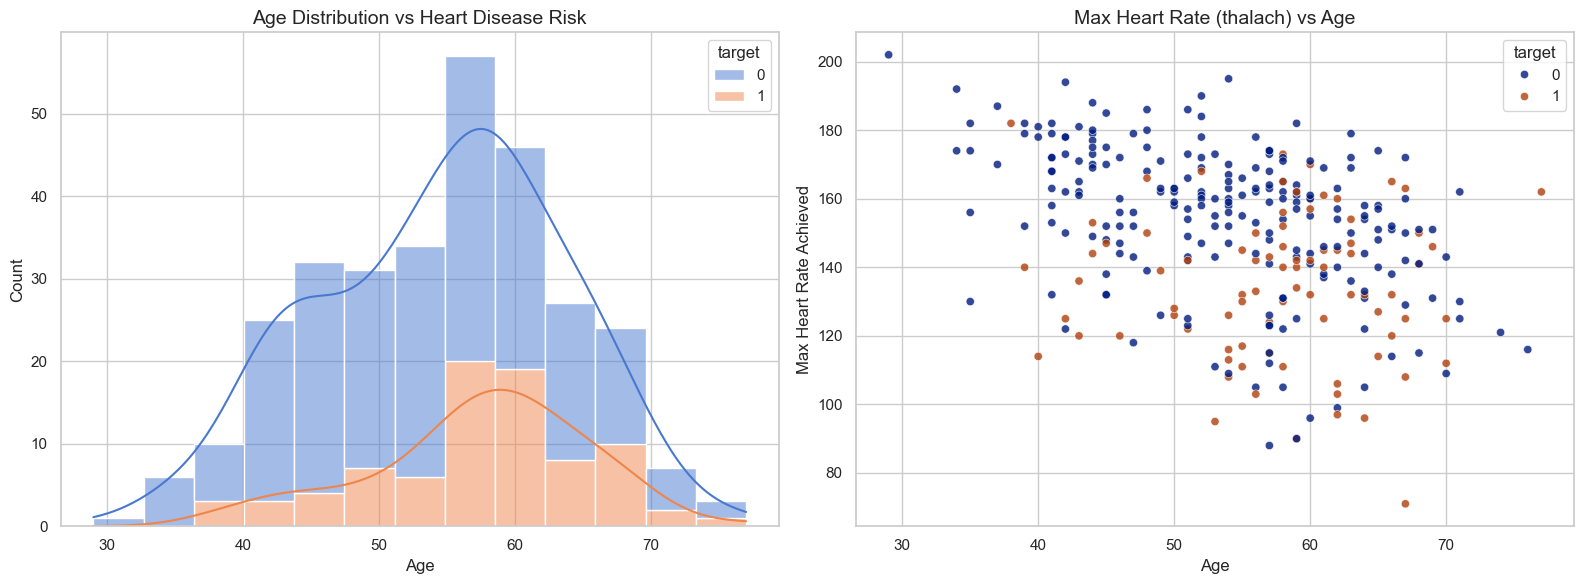

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(
    ax=axes[0],
    data=df,
    x="age",
    hue="target",
    kde=True,
    multiple="stack",
    palette="muted",
)
axes[0].set_title("Age Distribution vs Heart Disease Risk", fontsize=14)
axes[0].set_xlabel("Age")

sns.scatterplot(
    ax=axes[1],
    data=df,
    x="age",
    y="thalach",
    hue="target",
    palette="dark",
    alpha=0.8,
)
axes[1].set_title("Max Heart Rate (thalach) vs Age", fontsize=14)
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Max Heart Rate Achieved")

plt.tight_layout()
plt.show()

In [6]:
X = df.drop(columns=["target"])
y = df["target"]

X_encoded = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print(f"Success! Model Training Complete.")
print(f"Test Accuracy Score: {accuracy_score(y_test, y_pred)*100:.2f}%")

Success! Model Training Complete.
Test Accuracy Score: 85.25%


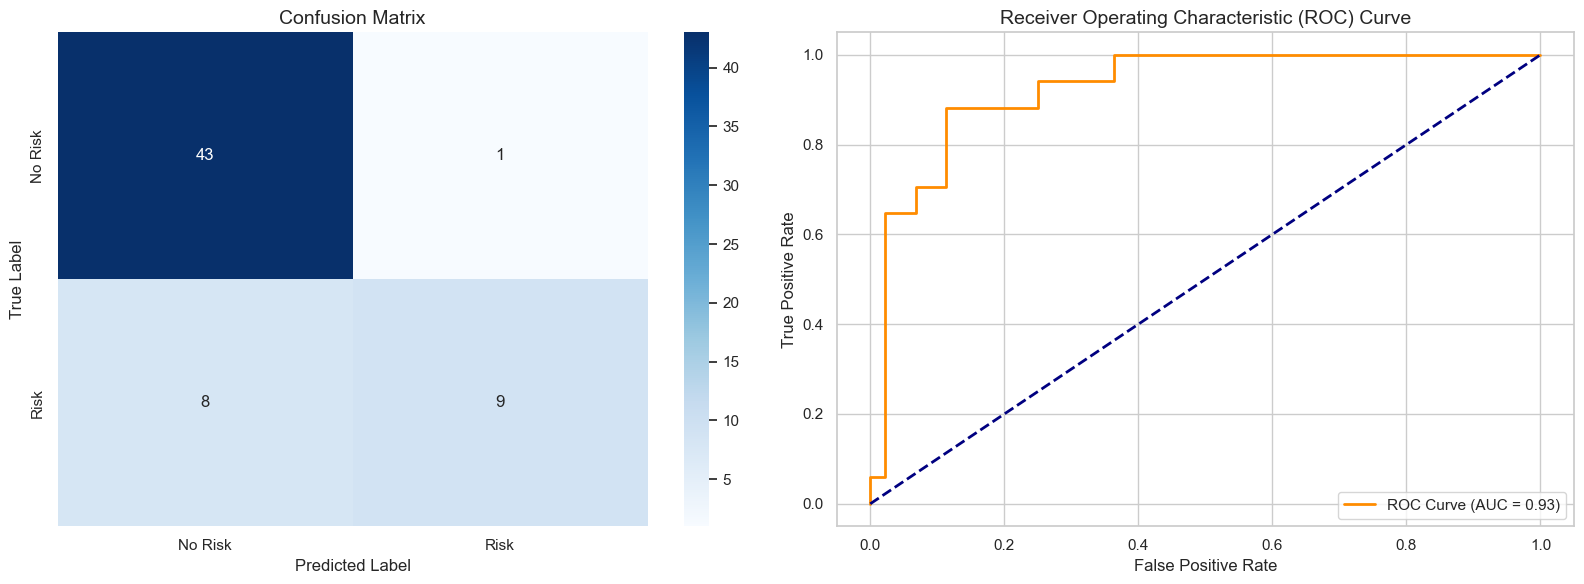

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

     No Risk       0.84      0.98      0.91        44
        Risk       0.90      0.53      0.67        17

    accuracy                           0.85        61
   macro avg       0.87      0.75      0.79        61
weighted avg       0.86      0.85      0.84        61



In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[0],
    xticklabels=["No Risk", "Risk"],
    yticklabels=["No Risk", "Risk"],
)
axes[0].set_title("Confusion Matrix", fontsize=14)
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

axes[1].plot(
    fpr,
    tpr,
    color="darkorange",
    lw=2,
    label=f"ROC Curve (AUC = {auc_score:.2f})",
)
axes[1].plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
axes[1].set_title("Receiver Operating Characteristic (ROC) Curve", fontsize=14)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred, target_names=["No Risk", "Risk"]))

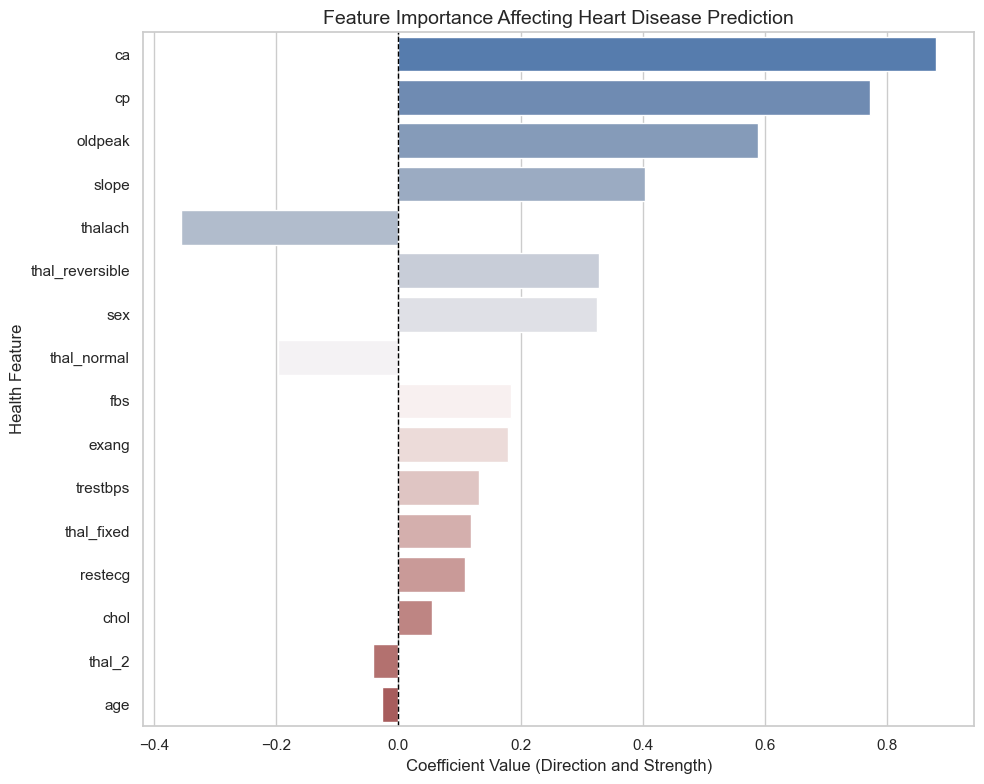

In [10]:
coefficients = model.coef_[0]

importance_df = pd.DataFrame(
    {"Feature": X_encoded.columns, "Importance (Coefficient)": coefficients}
).sort_values(by="Importance (Coefficient)", key=abs, ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(
    data=importance_df,
    x="Importance (Coefficient)",
    y="Feature",
    hue="Feature",  
    palette="vlag",
    legend=False,  
)

plt.title("Feature Importance Affecting Heart Disease Prediction", fontsize=14)
plt.xlabel("Coefficient Value (Direction and Strength)")
plt.ylabel("Health Feature")
plt.axvline(x=0, color="black", linestyle="--", linewidth=1)
plt.tight_layout()
plt.show()